# Description

I want to compare models run with "orbital_decay" and "trend" as target. For this I have trained 3 models for each target using Lasso.

# Imports

In [2]:
# import os
# os.nice(19)
# flake8: noqa: E402
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import root_mean_squared_error, r2_score
from pathlib import Path
from utils.data_loader import find_repo_root
from utils.modeling import aggregate_multistep_predictions
import joblib
import re

# Settings

In [3]:
sampling_rate = '5min'  # available: '20s', '1min', '5min'
start_time = '2024-07-24 00:00:00'
end_time = '2024-12-31 12:59:00'
columns =['orbital_decay', 'trend', '|avg B|', 'F10.7 (LASP)']
targets = ['orbital_decay', 'trend']
m = 15
dt_seconds = pd.to_timedelta(sampling_rate).total_seconds()

# Load Data

In [4]:
DATA_DIR = find_repo_root() / Path("Dataset/modeling/")
DATA_file = DATA_DIR / Path(f"GFOC_modeling_{sampling_rate}.parquet")
GFOC_data = pd.read_parquet(DATA_file, columns=columns)
# filter by time range
GFOC_data = GFOC_data.loc[start_time:end_time]
print(f"✅ Successfully loaded data with shape: {GFOC_data.shape}")
# column names
print("Column names in the dataset:")
print(GFOC_data.columns.tolist())
print("Sample rate:", pd.infer_freq(GFOC_data.index))

X_file = DATA_DIR / Path(f"X_{sampling_rate}.parquet")
X_test = pd.read_parquet(X_file)
X_test = X_test.loc[start_time:end_time]
y_tests = []
for target in targets:
    y_file = DATA_DIR / Path(f"y_{target}_{sampling_rate}.parquet")
    y_test = pd.read_parquet(y_file)
    y_test = y_test.loc[start_time:end_time]
    y_tests.append(y_test)
y_test_to_target = {
    name: y_tests[i % len(y_tests)]
    for i, name in enumerate(sorted(targets))
}
print(f"✅ Successfully loaded features X_test with shape: {X_test.shape} and target y_test with shape: {y_test.shape}")

✅ Successfully loaded data with shape: (46236, 4)
Column names in the dataset:
['orbital_decay', 'trend', '|avg B|', 'F10.7 (LASP)']
Sample rate: 5min
✅ Successfully loaded features X_test with shape: (46224, 538) and target y_test with shape: (46224, 48)


## Compare y_test for orbital decay and trend

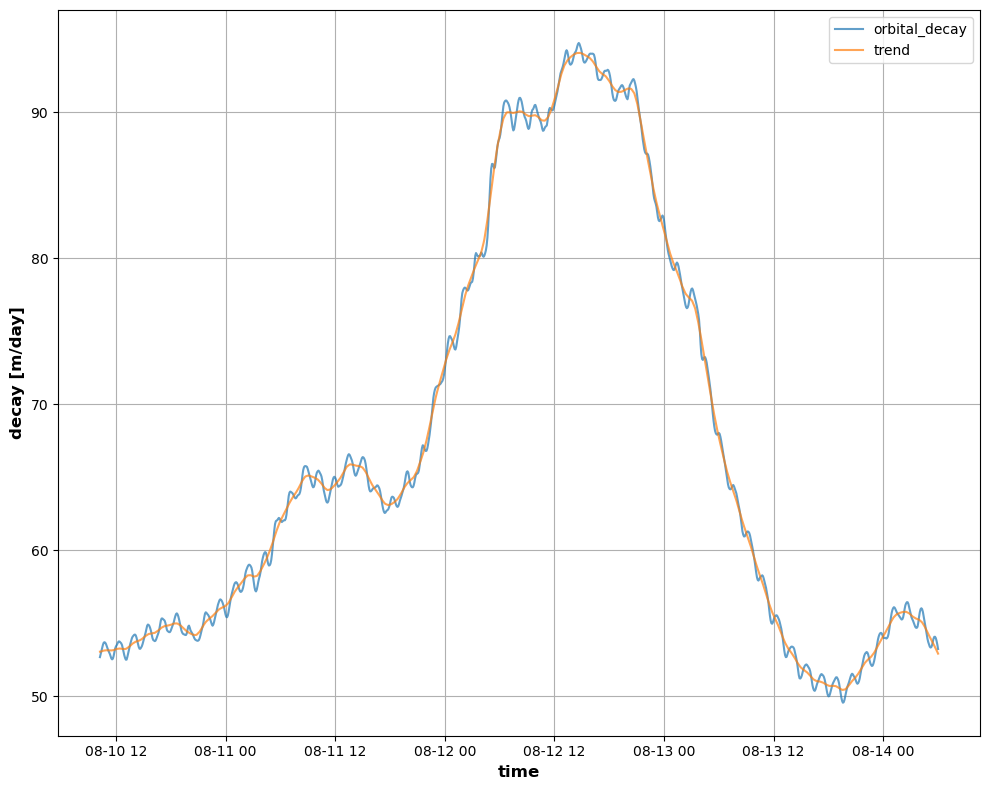

In [12]:
s_time = '2024-08-10 10:00:00'
e_time = '2024-08-13 18:00:00'
fig, ax = plt.subplots(1, 1, figsize=(10, 8), sharex=True)
for target in targets:
    y_test = y_test_to_target[target]
    y_test = y_test.loc[s_time:e_time]
    od_test = aggregate_multistep_predictions(y_test, dt_seconds=dt_seconds, m = m, error_kind='sem', test = True)
    # ax.plot(y_test.index, y_test.iloc[:, 0], label=f'{target}', alpha=0.7)
    ax.plot(od_test.index, od_test['mean'], label=f'{target}', alpha=0.7)
ax.set_ylabel(f'decay [m/day]')
ax.set_xlabel('time')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()


# Load Models

In [ ]:
MODEL_DIR = find_repo_root() / Path("Analysis/modeling/saved_models")

# load all models with joblib
model_types = ['lasso']
models = {}
scalers = {}

# regex to parse filenames
pattern = re.compile(
    r'(?P<model_type>.+?)_(?P<target>.+?)_(?P<kind>model|scaler)_(?P<number>\d+)\.pkl'
)

# --- sort files deterministically ---
pkl_files = sorted(
    MODEL_DIR.glob("*.pkl"),
    key=lambda p: (
        # extract number for numeric sorting
        int(pattern.match(p.name).group("number"))
        if pattern.match(p.name)
        else float("inf"),
        p.name,  # tie-breaker for absolute determinism
    ),
)

for pkl_file in pkl_files:
    match = pattern.match(pkl_file.name)
    if not match:
        continue

    model_type = match.group("model_type")
    target = match.group("target")
    kind = match.group("kind")
    number = int(match.group("number"))

    if model_type not in model_types:
        continue

    # nested structure: models[model_type][target][number]
    if kind == "model":
        models.setdefault(model_type, {}).setdefault(target, {})[number] = (
            joblib.load(pkl_file)
        )

    elif kind == "scaler":
        scalers.setdefault(model_type, {}).setdefault(target, {})[number] = (
            joblib.load(pkl_file)
        )
# check if for each model there is a corresponding scaler
for model_type in models:
    for target in models[model_type]:
        for number in models[model_type][target]:
            assert number in scalers[model_type][target], f"Scaler missing for {model_type} {target} {number}"
print(f"✅ Successfully loaded models and scalers for model types: {list(models.keys())}")

✅ Successfully loaded models and scalers for model types: ['lasso']


Show all models

In [ ]:
print("Loaded models:\n")

for model_type, targets in models.items():
    print(f"Model type: {model_type}")
    for target, model_nums in targets.items():
        nums = sorted(model_nums.keys())
        print(f"  Target: {target}")
        print(f"    Models: {nums}")
    print()

Loaded models:

Model type: lasso
  Target: orbital_decay
    Models: [1, 3, 4]
  Target: trend
    Models: [1, 2, 3, 4]



# Run Model

In [ ]:
predictions = {}

for model_type, targets in models.items():
    for target, model_nums in targets.items():
        for n, model in model_nums.items():

            scaler = scalers[model_type][target][n]
            y_test = y_test_to_target[target]

            # scale X_test
            X_test_scaled = pd.DataFrame(
                scaler.transform(X_test),
                index=X_test.index,
                columns=X_test.columns
            )

            # predict
            y_test_pred = pd.DataFrame(
                model.predict(X_test_scaled),
                index=X_test.index,
                columns=y_test.columns
            )

            # store
            predictions.setdefault(model_type, {}) \
                       .setdefault(target, {})[n] = y_test_pred

# Results

In [ ]:
def plot_scores(model_types, targets, numbers):
    fix, ax = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
    for model_type in model_types:
        for target in targets:
            for number in numbers:
                y_test_pred = predictions[model_type][target][number]
                y_test = y_test_to_target[target]
                xtest = [int(col.split('_')[-1]) for col in y_test.iloc[0].index]
            
                test_rmse = root_mean_squared_error(y_test, y_test_pred)
                test_r2 = r2_score(y_test, y_test_pred)

                test_rmse_list = []
                test_r2_list = []

                for i in range(len(y_test.columns)):
                    test_rmse_list.append(root_mean_squared_error(y_test.iloc[:, i], y_test_pred.iloc[:, i]))
                    test_r2_list.append(r2_score(y_test.iloc[:, i], y_test_pred.iloc[:, i]))

                model_label = f"{model_type} {target} {number}"
                # select linestyle based on model type
                if target == 'trend':
                    linestyle = '-'
                elif target == 'orbital_decay':
                    linestyle = '--'
                else:
                    linestyle = ':'
                ax[0].plot(xtest,test_rmse_list, label=f'{model_label}, Test RMSE: {test_rmse:.3}', linestyle=linestyle, alpha=0.7)
                ax[1].plot(xtest, test_r2_list, label=f'{model_label}, Test R2: {test_r2:.3}', linestyle=linestyle, alpha=0.7)
    ax[0].set_ylabel('RMSE')
    ax[0].legend()
    ax[0].grid(True)

    ax[1].set_ylabel('R2 Score')
    ax[1].set_xlabel('Forecast Step (20s intervals)')
    ax[1].legend()
    ax[1].grid(True)
    plt.tight_layout()
    plt.show()

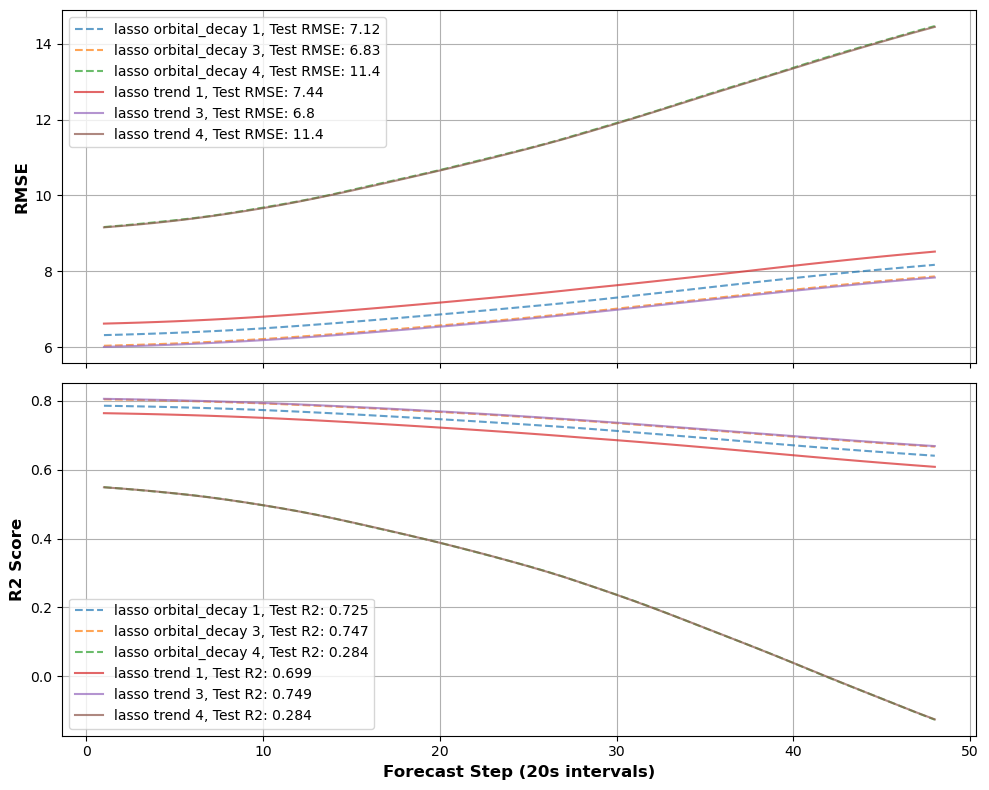

In [ ]:
model_types = ['lasso']
targets = ['orbital_decay', 'trend']
numbers = [1,3,4]

plot_scores(model_types, targets, numbers)

## Plot aggregated multistep predictions

In [ ]:
def plot_agg(start_time, end_time,model_types, targets, numbers):
    for model_type in model_types:
        for number in numbers:
            fix, ax = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
            for target in targets:
                y_test_pred = predictions[model_type][target][number]
                y_test = y_test_to_target[target]
                
                od_test = aggregate_multistep_predictions(y_test, dt_seconds=dt_seconds, m = m, error_kind='sem', test = True)
                od_test_pred = aggregate_multistep_predictions(y_test_pred, dt_seconds=dt_seconds, m = m, error_kind='sem')

                # filter for time range
                od_test = od_test.loc[start_time:end_time]
                od_test_pred = od_test_pred.loc[start_time:end_time]

                model_label = f"{model_type} {target} {number}"
                # select linestyle based on model type
                if target == 'trend':
                    linestyle = '-'
                    i = 0
                elif target == 'orbital_decay':
                    linestyle = '--'
                    i = 1
                else:
                    linestyle = ':'
                
                ax[i].plot(od_test.index, od_test['mean'], color='black')
                ax[i].plot(od_test_pred.index, od_test_pred['mean'], color='C0')
                ax[i].fill_between(od_test_pred.index, od_test_pred['mean'] - 1.96 *od_test_pred['sem'], od_test_pred['mean'] + 1.96 *od_test_pred['sem'], color='C0', alpha=0.3)
                ax[i].plot(od_test_pred.index, od_test_pred['horizon0'], color='green',  alpha=0.3)
                _ = ax[i].legend(['True Trend (test)', 'Mean Prediction', '95% Prediction Band', 'Raw Prediction at horizon 0'])
                ax[i].set_title(f"Testing {target}: RMSE = {root_mean_squared_error(y_test, y_test_pred):.2f}, R2 = {r2_score(y_test, y_test_pred):.2f}")

            ax[0].set_ylabel('trend [m/day]')

            ax[1].set_ylabel('orbital_decay [m/day]')
            ax[1].set_xlabel('time')
            plt.tight_layout()
            plt.show()

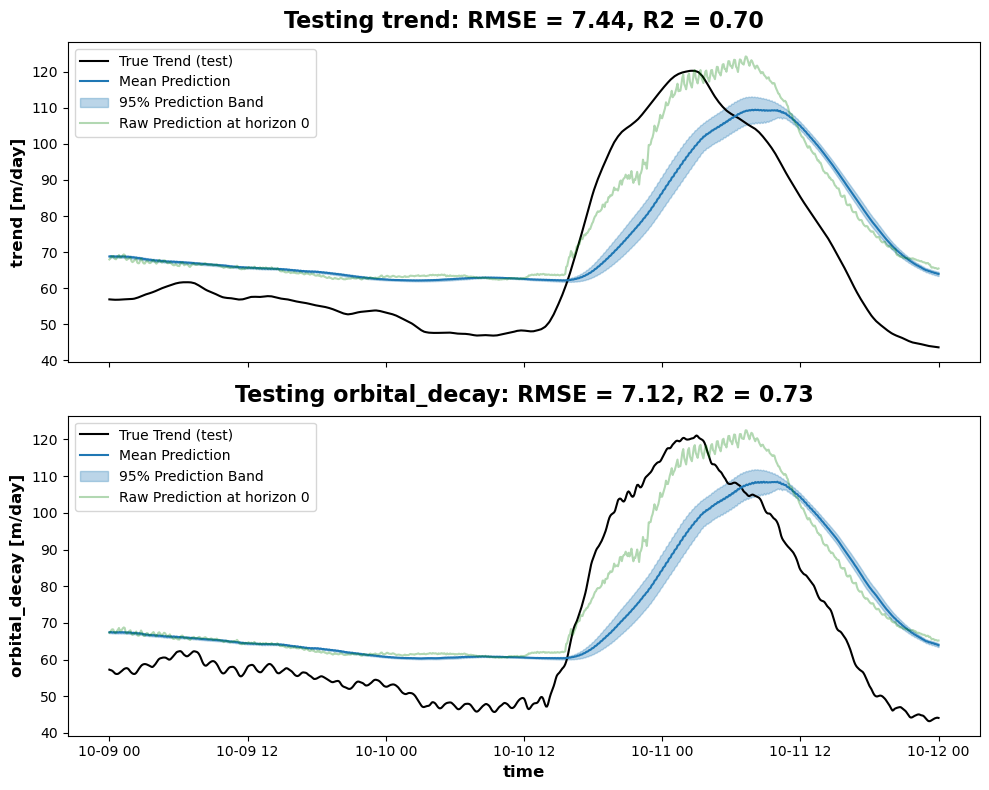

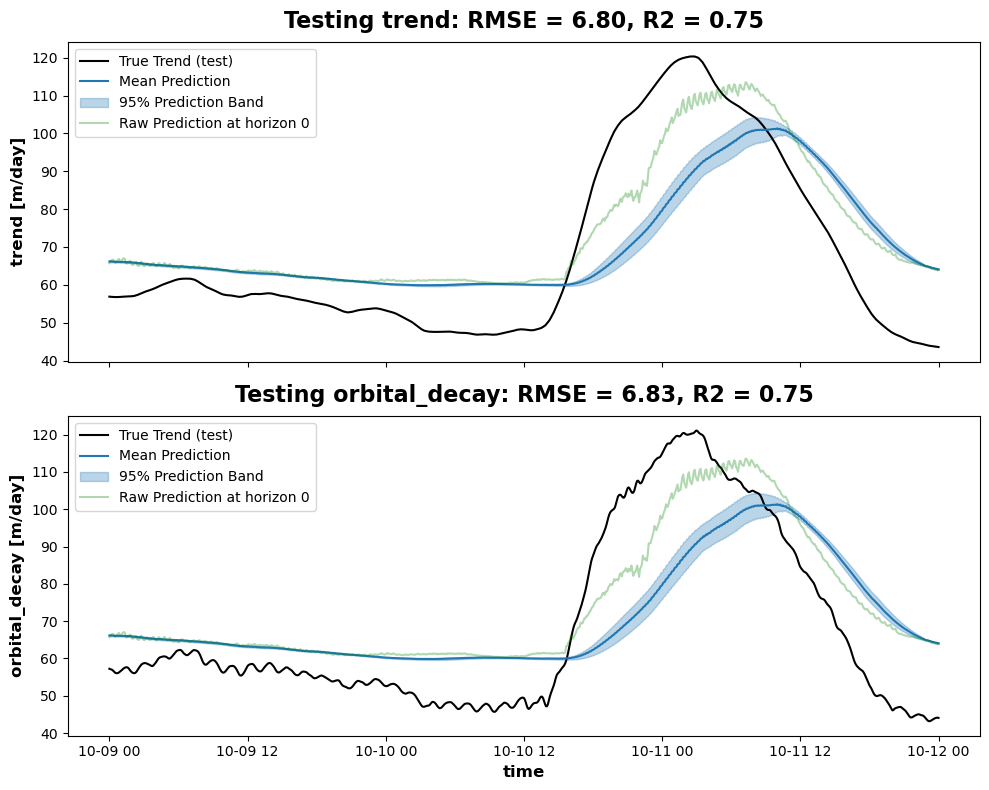

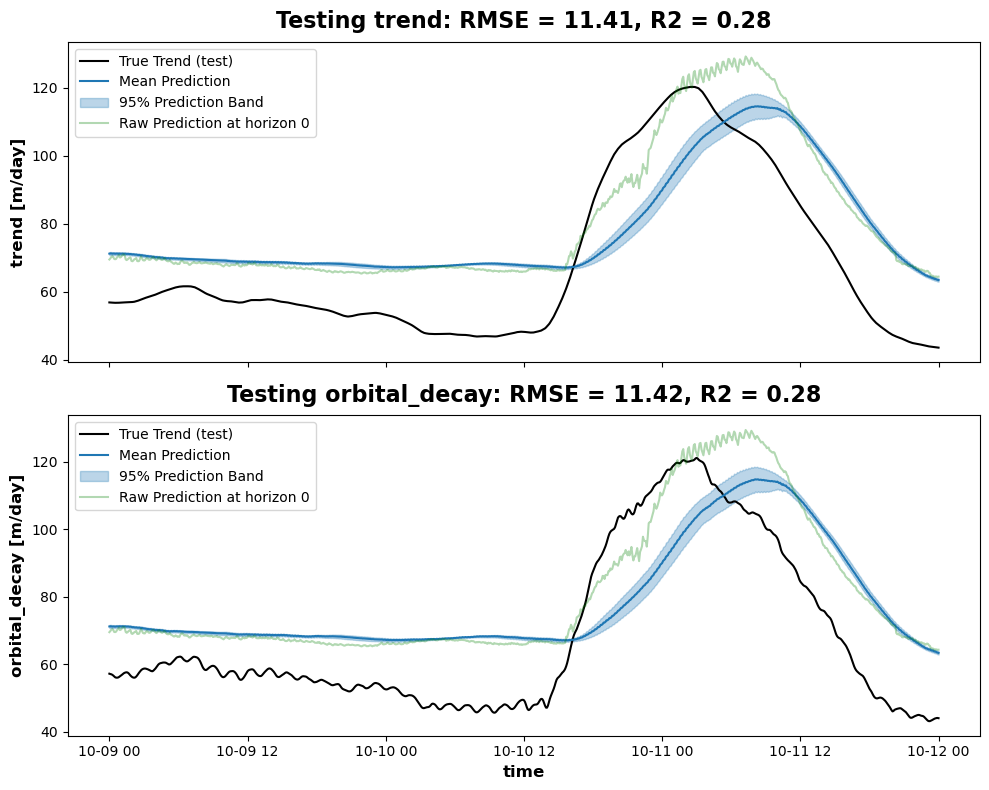

In [ ]:
model_types = ['lasso']
targets = ['orbital_decay', 'trend']
numbers = [1,3,4]
start_time = '2024-10-09 00:00:00'
end_time = '2024-10-12 00:00:00'

plot_agg(start_time, end_time, model_types, targets, numbers)